# Weekly project part 1
Using the image "appletree.jpg"
1) Can you segment the apples from the tree?
2) Can you get the computer to count how many there are? 
    How close can you get to the ground truth? (there are 26 apples in the image)
3) Can you change the color of one of them?
4) Can you segment the leaves?
    
    
# Weekly project part 2
1) Remove the greenscreen and replace the background in "itssp.png".
2) Can you improve the edge with eroding/dilating?


In [2]:
import cv2
import numpy as np
import imutils
from matplotlib import pyplot as plt
from matplotlib.colors import hsv_to_rgb

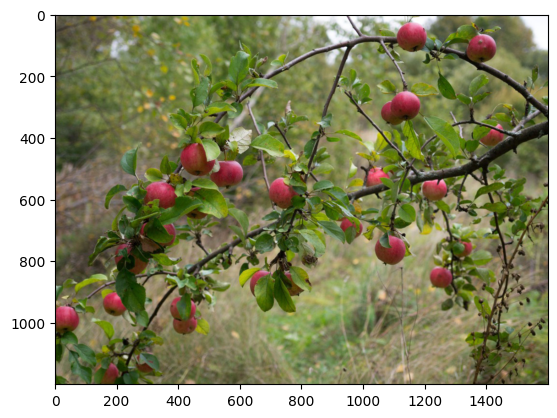

In [4]:
apple = "appletree.jpg"
bgr = cv2.imread(apple)
b, g, r = cv2.split(bgr)

apple_img = cv2.merge([r, g, b])
plt.imshow(apple_img)

In [5]:
color = apple_img[1050, 550]
print(color)

[143 138 106]


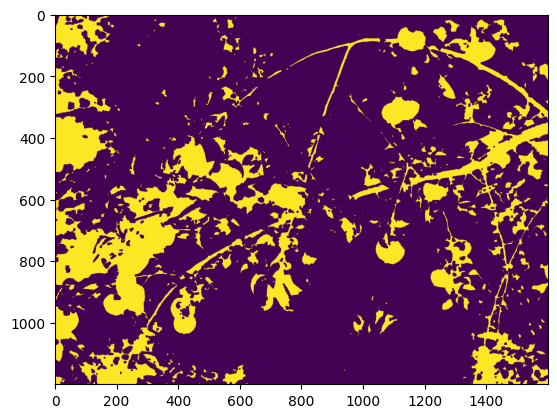

In [6]:
output = apple_img.copy()
upper = np.array([255, 100, 110])
lower = np.array([0, 0, 0])
mask = cv2.inRange(output, lower, upper)

plt.imshow(mask)

mask = cv2.erode(mask, None, iterations = 2)
plt.imshow(mask)

In [7]:
#too much noise in rgb

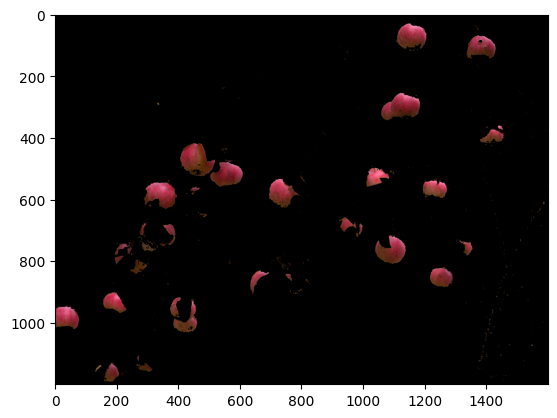

In [8]:
#HSV tryout
img = apple_img.copy()
hsv_image = cv2.cvtColor(apple_img, cv2.COLOR_RGB2HSV)

lower_red_1 = np.array([0, 125, 0])
upper_red_1 = np.array([15, 255, 255])
lower_red_2 = np.array([165, 100, 0])
upper_red_2 = np.array([180, 255, 255])

mask1 = cv2.inRange(hsv_image, lower_red_1, upper_red_1)
mask2 = cv2.inRange(hsv_image, lower_red_2, upper_red_2)

result1 = cv2.bitwise_and(img, img, mask=mask1)
result2 = cv2.bitwise_and(img, img, mask=mask2)
results = cv2.bitwise_or(result1, result2)
plt.imshow(results)

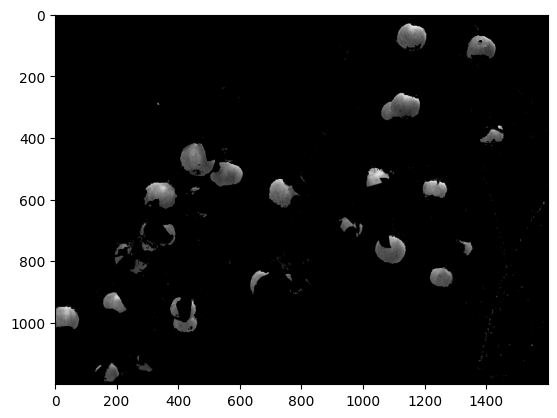

In [9]:
#Convert to gray

gray = cv2.cvtColor(results, cv2.COLOR_RGB2GRAY)
plt.imshow(gray, cmap = "gray")

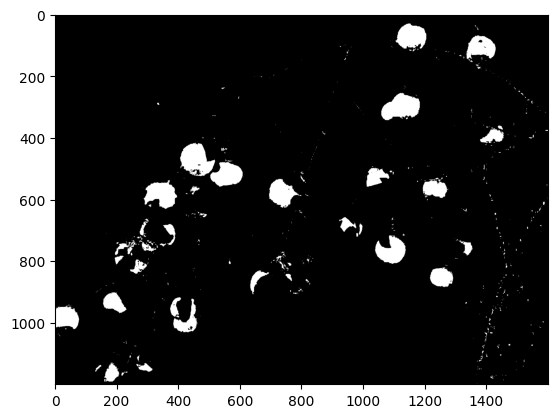

In [10]:
threshold = 0
threshold_value = 255

thresh = cv2.threshold(gray, threshold, threshold_value, cv2.THRESH_BINARY)[1]
plt.imshow(thresh, cmap='gray')

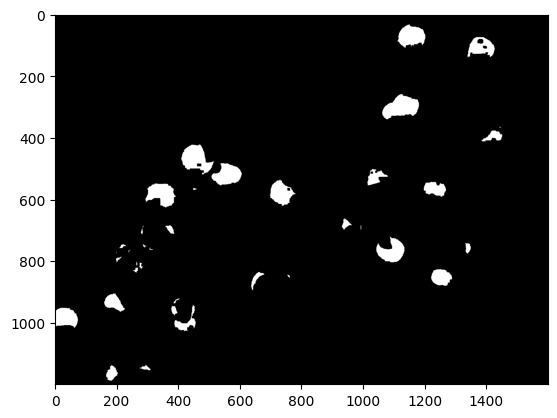

In [11]:
erode_mask = thresh.copy()
erode_mask = cv2.erode(erode_mask, None, iterations = 3)
plt.imshow(erode_mask, cmap = "gray")

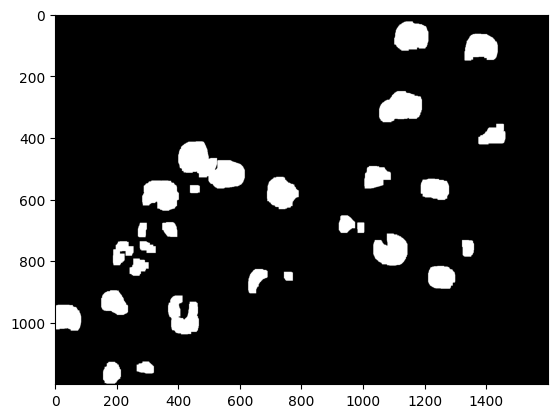

In [12]:
dilate_mask = erode_mask.copy()
dilate_mask = cv2.dilate(dilate_mask, None ,iterations = 10)
plt.imshow(dilate_mask, cmap="gray")

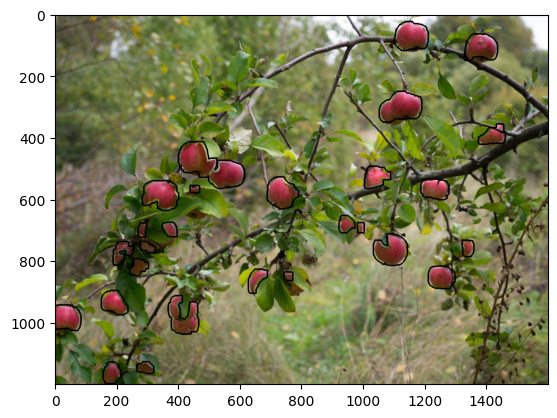

In [13]:
cnts = cv2.findContours(dilate_mask.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnts = imutils.grab_contours(cnts)
output = apple_img.copy()
for c in cnts:
    # draw each contour on the output image with a 3px thick black outline
    cv2.drawContours(output, [c], -1, (0, 0, 0), 3)
    
plt.imshow(output)

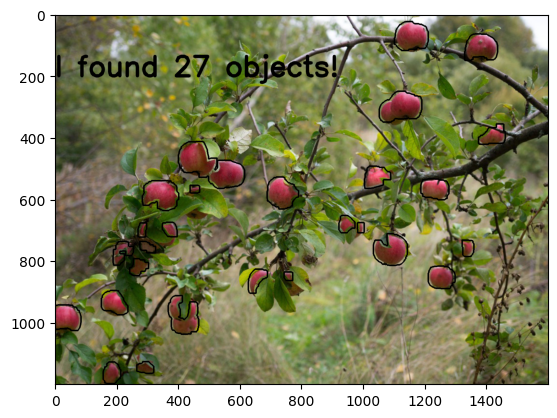

In [14]:
text = "I found {} objects!".format(len(cnts))
text_copy = output.copy()
cv2.putText(text_copy, text, (0, 200),  cv2.FONT_HERSHEY_SIMPLEX, 3, (0, 0, 0), 10)
plt.imshow(text_copy)

In [15]:
cnts = cv2.findContours(dilate_mask.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnts = imutils.grab_contours(cnts)
(h, w, d) = output.shape

max_x = 0
max_y = 0
min_x = h
min_y = w

for i in cnts[1]:
    for j in i:
        if j[0]>max_x:
            max_x = j[0]
        if j[0]<min_x:
            min_x = j[0]
        if j[1]>max_y:
            max_y = j[1]
        if j[1]<min_y:
            min_y = j[1]

In [16]:
print(max_x, min_x, max_y, min_y)
#cv2.boundingRect

320 265 1165 1127


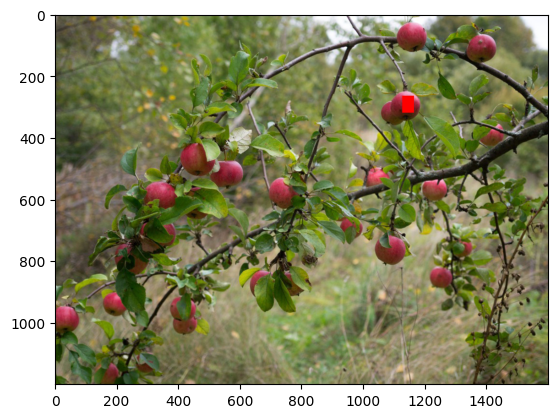

In [17]:
result = np.zeros_like(apple_img)
result_2 = apple_img.copy()
result_2[min_x:max_x,min_y:max_y] = (255,0,0)
plt.imshow(result_2)

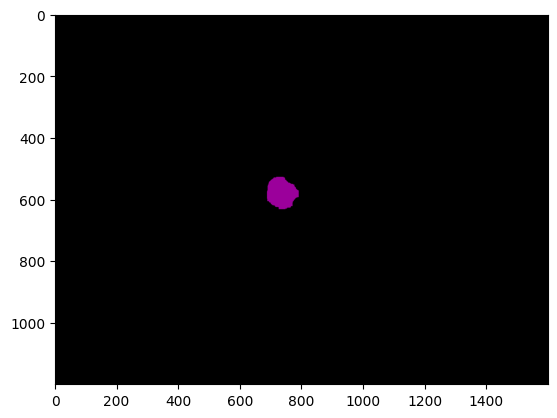

In [18]:
h, w, d = apple_img.shape
blank_image = np.zeros((h,w,3), np.uint8)
cnts = cv2.findContours(dilate_mask.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnts = imutils.grab_contours(cnts)
#for c in cnts:
    # draw each contour on the output image with a 3px thick black outline

cv2.drawContours(blank_image, [cnts[20]], -1, (155, 0, 155), cv2.FILLED)
plt.imshow(blank_image)

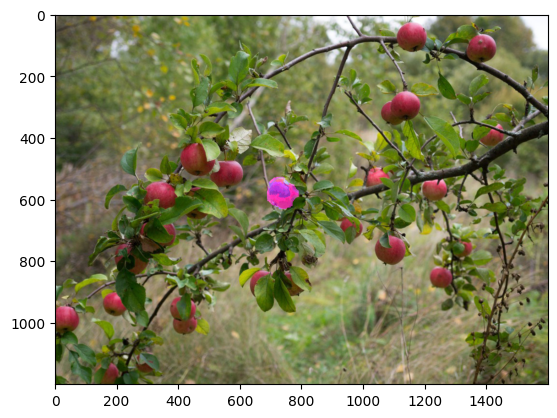

In [19]:
color_switch = cv2.bitwise_or(apple_img.copy(), blank_image.copy(), mask = None)
plt.imshow(color_switch)

### Part 2, It's time to stop
Down is part 2 of the weekly exercise

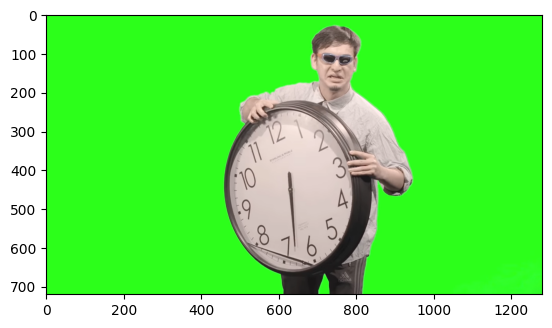

In [20]:
bgr_img = cv2.imread("ittsp.png")
[b, g, r] = cv2.split(bgr_img)
image = cv2.merge([r, g, b])
plt.imshow(image)

In [21]:
(h, w, d) = image.shape
print("height = {}, width = {}, d = {}".format(h, w, d))
(R, G, B) = image[100, 100]
print("R = {}, G = {} B = {}".format(R, G, B))

height = 720, width = 1280, d = 3
R = 44, G = 255 B = 26


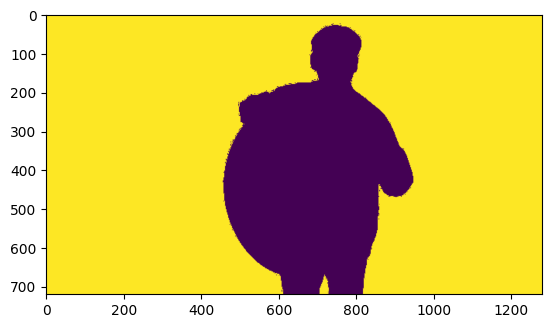

In [22]:
output = image.copy()
upper = np.array([70, 255, 60])
lower = np.array([40, 245, 22])
mask = cv2.inRange(output, lower, upper)
plt.imshow(mask)

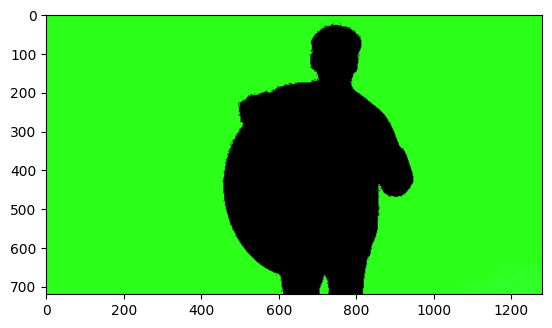

In [23]:
output = image.copy()
res = cv2.bitwise_and(output, output, mask = mask)

plt.imshow(res)

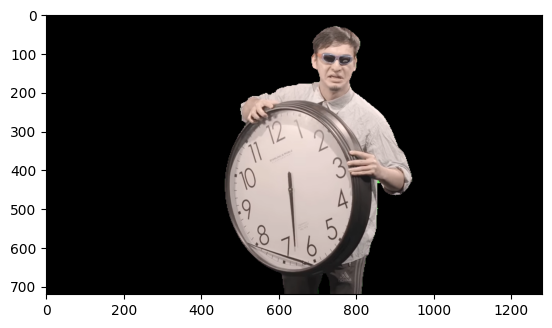

In [24]:
threshold = 225
threshold_value = 255

thresh = cv2.threshold(mask, threshold, threshold_value, cv2.THRESH_BINARY)[1]
plt.imshow(thresh, cmap='gray')
threshold = cv2.dilate(thresh, None, iterations = 3)
k1 = cv2.bitwise_and(output, output, mask = threshold)
k = output - k1
plt.imshow(k)

In [25]:
(h, w, d) = k.shape
bgr_img_2 = cv2.imread("appletree.jpg")
(B2, G2, R2) = cv2.split(bgr_img_2)
apples = cv2.merge([R2, G2, B2])
(b2, w2, d2) = apples.shape
apples_resized = cv2.resize(apples, (w, h))


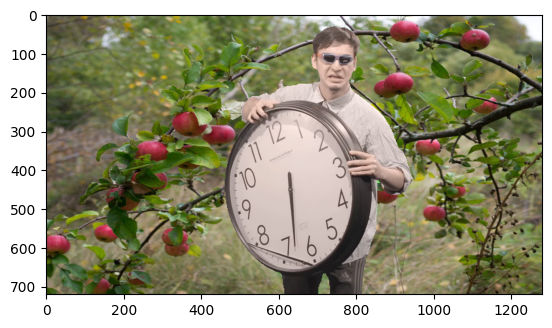

In [26]:
joint = np.where(k == 0, apples_resized, k)
plt.imshow(joint)

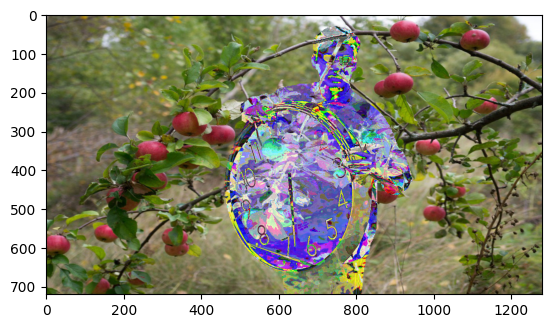

In [27]:
joint_2 = cv2.bitwise_xor(apples_resized, k)
plt.imshow(joint_2)

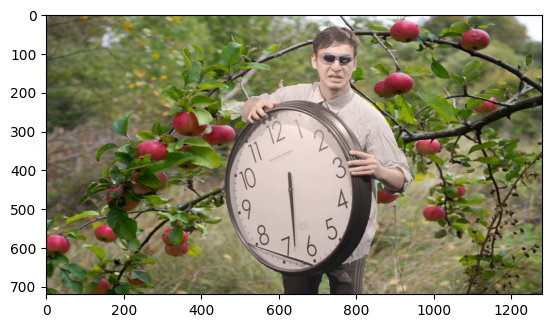

In [28]:
apples_cut = cv2.bitwise_and(apples_resized, apples_resized, mask = threshold)
joint_3 = cv2.add(apples_cut, k)
plt.imshow(joint_3)

Below is our attempt to segment the leaves

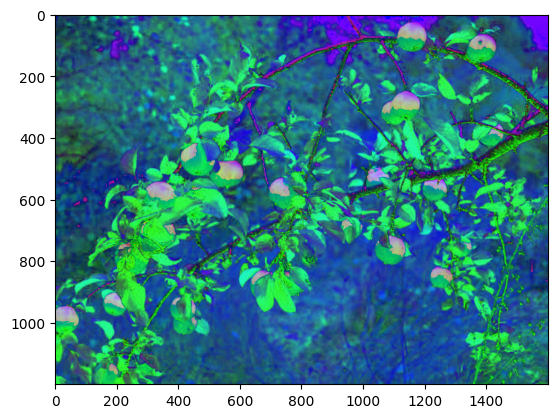

In [29]:
# first, we convert the image to HSV, since there are a range of colors for the leaves that may be far apart in the RBG color space
bgr_img_3 = cv2.imread("appletree.jpg")
leaf_hsv_image = cv2.cvtColor(bgr_img_3, cv2.COLOR_BGR2HSV)
plt.imshow(leaf_hsv_image)

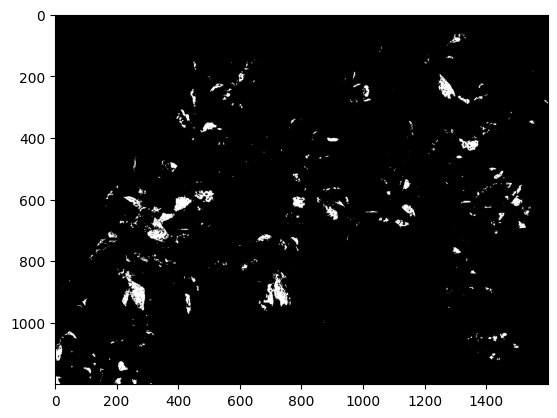

In [30]:
# We pick a pixel of a known leaf and get the HSV values for it
hue = leaf_hsv_image[1199][200][0]
saturation = leaf_hsv_image[1199][200][1]
value = leaf_hsv_image[1199][200][2]

# Then, create a mask around those values
hue_mask = cv2.threshold(leaf_hsv_image[:,:,0], (hue-10), hue+10, cv2.THRESH_BINARY)[1]
saturation_mask = cv2.threshold(leaf_hsv_image[:,:,1], saturation-10, saturation+3, cv2.THRESH_BINARY)[1]
value_mask = cv2.threshold(leaf_hsv_image[:,:,2], value-10, value+10, cv2.THRESH_BINARY)[1]

combined_mask = hue_mask & saturation_mask & value_mask
plt.imshow(combined_mask, cmap = "gray")

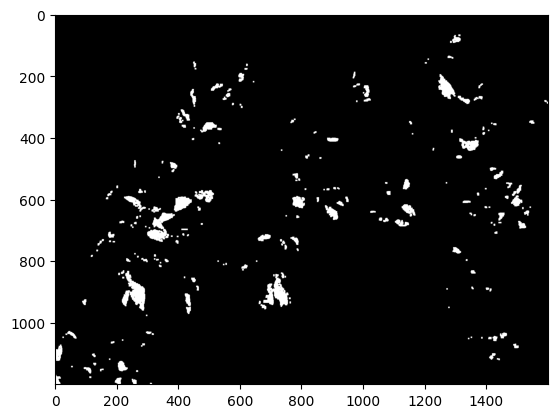

In [31]:
# erode and dialate
eroded_mask = cv2.erode(combined_mask, None, iterations=1)
dialated_mask = cv2.dilate(eroded_mask, None, iterations=2)

plt.imshow(dialated_mask, cmap="gray")

Found 223 contours


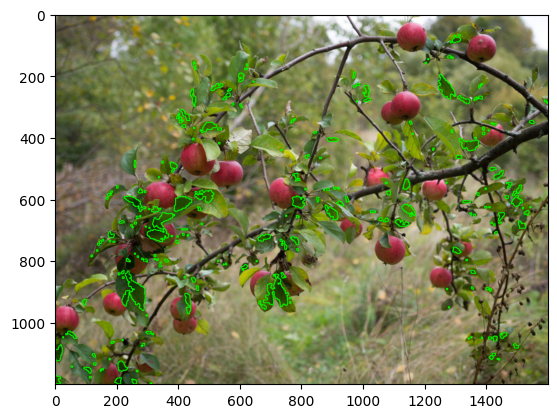

In [32]:
# countour to segment the leaves
cnts = cv2.findContours(dialated_mask.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnts = imutils.grab_contours(cnts)
print(f"Found {len(cnts)} contours")

result = bgr_img_3.copy()
cv2.drawContours(result, cnts, -1, (0, 255, 0), 2)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))

We are not picking up some of the leaves or parts of leaves which are a distinctly different hue/saturation than the current selection.  But we did not get around to fixing this, and also thought it might better to under-count than over-count, given that the background objects can very easily translate to a high number of false positives.